# **BUS638 - Project**
Authors: Reem Anwar, Sonja Skura

## **Title:** Brain Tumor Image Classification Using Convolutional Neural Networks

In [3]:
# Import Libraries
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
#unzip dataset
zip_path = "/content/drive/MyDrive/archive (1).zip"
extract_path = "brain_tumor_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Testing', 'Training']


In [6]:
#Set dataset Paths
train_dir = os.path.join(extract_path, "Training")
test_dir = os.path.join(extract_path, "Testing")

print("Training folders:", os.listdir(train_dir))
print("Testing folders:", os.listdir(test_dir))

Training folders: ['glioma', 'pituitary', 'meningioma', 'notumor']
Testing folders: ['glioma', 'pituitary', 'meningioma', 'notumor']


In [7]:
# data loading and preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [9]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5600
Testing images: 1600


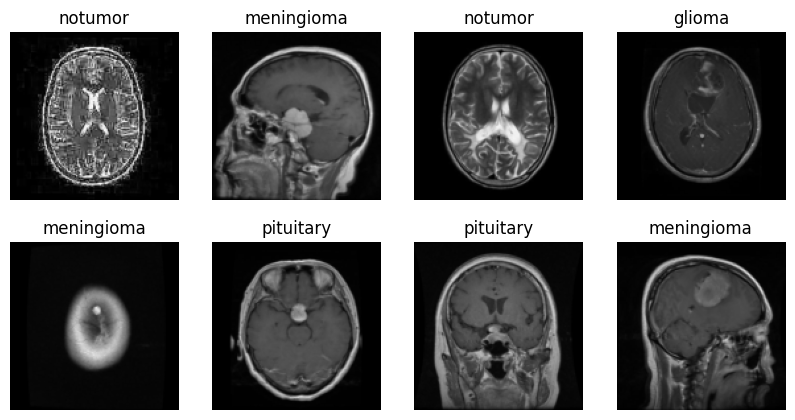

In [12]:
#example images
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(8):
    img = images[i] / 2 + 0.5
    img = np.transpose(img.numpy(), (1, 2, 0))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [33]:
# Basic CNN Model
class BasicCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BasicCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [34]:
# Loss Function and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BasicCNN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

BasicCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [35]:
# Train Basic CNN
epochs = 15

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/15], Loss: 0.7646, Accuracy: 70.39%
Epoch [2/15], Loss: 0.4801, Accuracy: 81.52%
Epoch [3/15], Loss: 0.3707, Accuracy: 85.84%
Epoch [4/15], Loss: 0.2989, Accuracy: 88.34%
Epoch [5/15], Loss: 0.2311, Accuracy: 91.34%
Epoch [6/15], Loss: 0.1905, Accuracy: 92.62%
Epoch [7/15], Loss: 0.1582, Accuracy: 93.91%
Epoch [8/15], Loss: 0.1292, Accuracy: 95.05%
Epoch [9/15], Loss: 0.1049, Accuracy: 96.14%
Epoch [10/15], Loss: 0.0937, Accuracy: 96.45%
Epoch [11/15], Loss: 0.0799, Accuracy: 97.16%
Epoch [12/15], Loss: 0.0689, Accuracy: 97.34%
Epoch [13/15], Loss: 0.0666, Accuracy: 97.64%
Epoch [14/15], Loss: 0.0665, Accuracy: 97.43%
Epoch [15/15], Loss: 0.0468, Accuracy: 98.48%


In [36]:
# Evaluate Basic CNN
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

basic_accuracy = 100 * correct / total

print(f"Basic CNN Test Accuracy: {basic_accuracy:.2f}%")

Basic CNN Test Accuracy: 87.19%


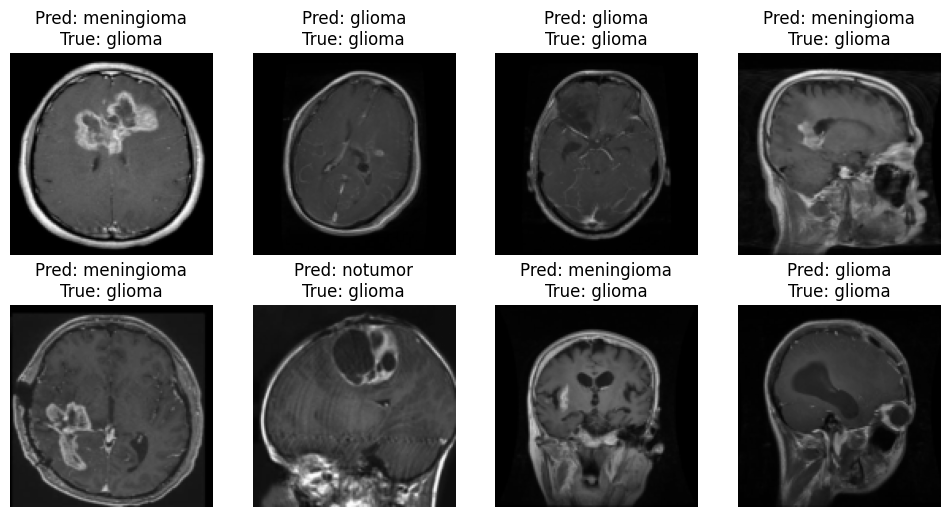

In [37]:
# Visualize Predictions
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))

for i in range(8):
    img = images[i].cpu() / 2 + 0.5
    img = np.transpose(img.numpy(), (1, 2, 0))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}")
    plt.axis("off")

plt.show()

In [27]:
# Improved CNN Model
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [28]:
# Train Improved CNN
improved_model = ImprovedCNN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

epochs = 15

improved_losses = []
improved_accuracies = []

for epoch in range(epochs):
    improved_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = improved_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    improved_losses.append(epoch_loss)
    improved_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/15], Loss: 0.8460, Accuracy: 71.88%
Epoch [2/15], Loss: 0.5136, Accuracy: 79.18%
Epoch [3/15], Loss: 0.4351, Accuracy: 81.98%
Epoch [4/15], Loss: 0.3790, Accuracy: 84.71%
Epoch [5/15], Loss: 0.3164, Accuracy: 87.29%
Epoch [6/15], Loss: 0.2733, Accuracy: 89.27%
Epoch [7/15], Loss: 0.2480, Accuracy: 89.86%
Epoch [8/15], Loss: 0.2334, Accuracy: 90.50%
Epoch [9/15], Loss: 0.2085, Accuracy: 91.54%
Epoch [10/15], Loss: 0.1748, Accuracy: 93.04%
Epoch [11/15], Loss: 0.1657, Accuracy: 93.36%
Epoch [12/15], Loss: 0.1455, Accuracy: 94.62%
Epoch [13/15], Loss: 0.1232, Accuracy: 95.38%
Epoch [14/15], Loss: 0.1266, Accuracy: 95.07%
Epoch [15/15], Loss: 0.1175, Accuracy: 95.66%


In [29]:
# Evaluate Imroved CNN
improved_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = improved_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

improved_accuracy = 100 * correct / total

print(f"Improved CNN Test Accuracy: {improved_accuracy:.2f}%")

Improved CNN Test Accuracy: 89.81%


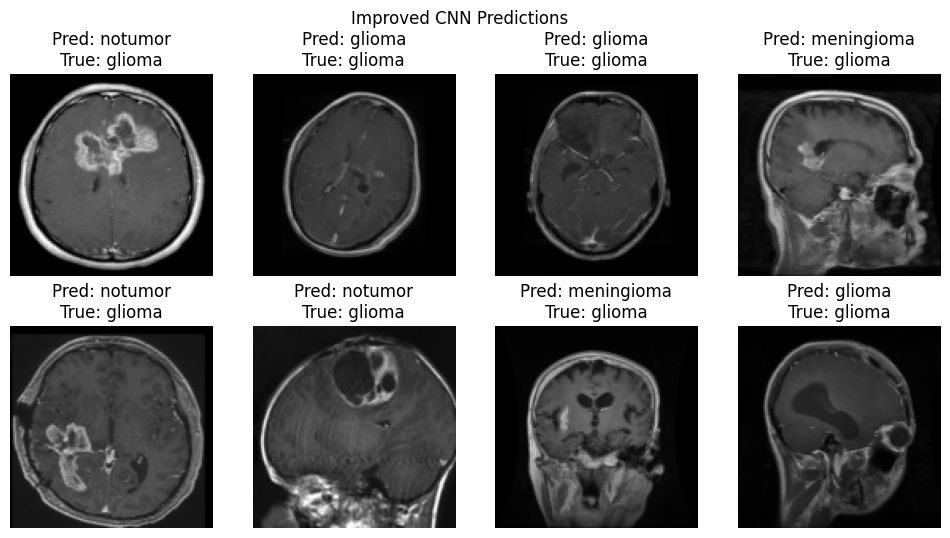

In [42]:
#Visualize Predictions (Improved CNN)
improved_model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = improved_model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))

for i in range(8):
    img = images[i].cpu() / 2 + 0.5
    img = np.transpose(img.numpy(), (1, 2, 0))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}")
    plt.axis("off")

plt.suptitle("Improved CNN Predictions")
plt.show()

In [30]:
#compare both models
print("Model Comparison")
print("----------------")
print(f"Basic CNN Accuracy: {basic_accuracy:.2f}%")
print(f"Improved CNN Accuracy: {improved_accuracy:.2f}%")

Model Comparison
----------------
Basic CNN Accuracy: 87.00%
Improved CNN Accuracy: 89.81%


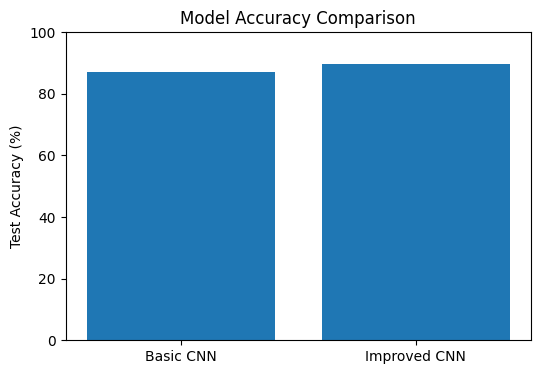

In [41]:
models = ["Basic CNN", "Improved CNN"]
accuracies = [basic_accuracy, improved_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.ylabel("Test Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

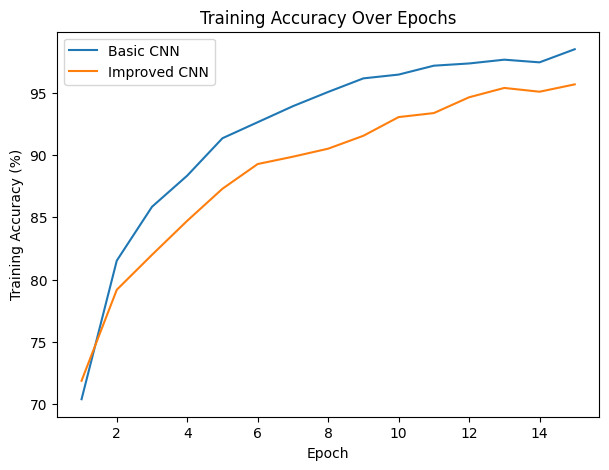

In [39]:
# plot training progress
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label="Basic CNN")
plt.plot(range(1, epochs + 1), improved_accuracies, label="Improved CNN")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Over Epochs")
plt.legend()
plt.show()

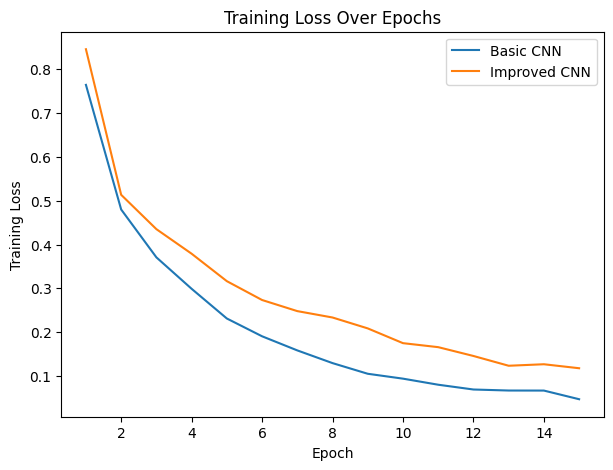

In [40]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Basic CNN")
plt.plot(range(1, epochs + 1), improved_losses, label="Improved CNN")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.show()

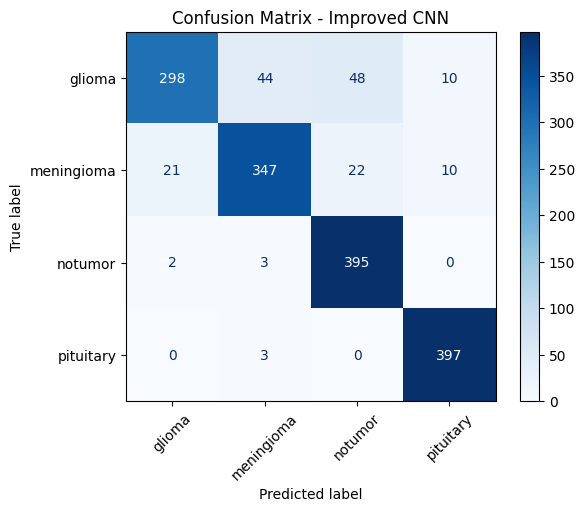

In [43]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

improved_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = improved_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Improved CNN")
plt.show()

In [44]:
# Classification Report
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=class_names)

print("Classification Report - Improved CNN")
print(report)

Classification Report - Improved CNN
              precision    recall  f1-score   support

      glioma       0.93      0.74      0.83       400
  meningioma       0.87      0.87      0.87       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [45]:
# putting results in a table
import pandas as pd

results = pd.DataFrame({
    "Model": ["Basic CNN", "Improved CNN"],
    "Test Accuracy (%)": [basic_accuracy, improved_accuracy]
})

results

,Model,Test Accuracy (%)
0,Basic CNN,87.1875
1,Improved CNN,89.8125


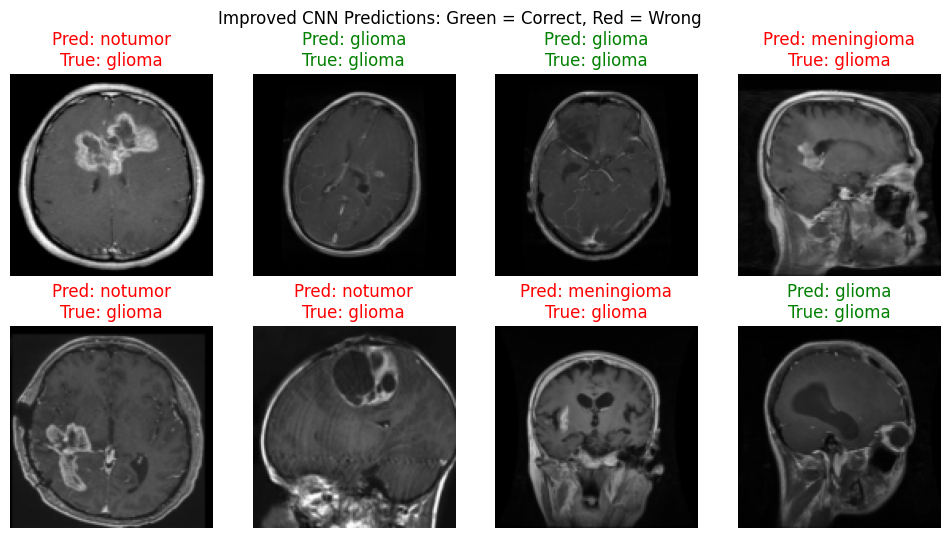

In [46]:
# Correct vs Wrong Predicitions
improved_model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = improved_model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))

for i in range(8):
    img = images[i].cpu() / 2 + 0.5
    img = np.transpose(img.numpy(), (1, 2, 0))

    correct = predicted[i] == labels[i]
    title_color = "green" if correct else "red"

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}",
        color=title_color
    )
    plt.axis("off")

plt.suptitle("Improved CNN Predictions: Green = Correct, Red = Wrong")
plt.show()

## Model Evaluation Summary

The Basic CNN achieved a test accuracy of 87.19%, while the Improved CNN achieved a test accuracy of 89.81%. The Improved CNN performed better, suggesting that adding batch normalization and an additional convolutional layer helped the model learn more useful image features from the MRI scans.

The confusion matrix and classification report provide more detail about model performance for each class. These results are useful because accuracy alone does not show which tumor categories were easier or harder for the model to classify.

Overall, the CNN model was effective for classifying brain MRI images into glioma, meningioma, notumor, and pituitary categories. However, the model still made some mistakes, especially when MRI images looked visually similar across tumor types.

## Impact Analysis and Insights

This project shows how convolutional neural networks can be applied to medical image classification. A CNN can learn visual patterns from MRI images and help support the classification of brain tumor types.

The model could be useful as a decision-support tool, but it should not replace medical professionals. One limitation is that the model was trained on a limited dataset, so performance may change when tested on MRI images from different hospitals or machines.

Future improvements could include using more training data, applying data augmentation, testing transfer learning models such as ResNet, and tuning hyperparameters such as learning rate, dropout rate, and number of epochs.